In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import scale
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error as mae

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

In [12]:
# 1. 평가 지표 함수 정의
def f1(y_true, y_pred):
    # Keras 텐서 연산을 위해 데이터 타입을 float32로 통일
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
                    
    def recall(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

    def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision
        
    precision_pos = precision(y_true, y_pred)
    recall_pos = recall(y_true, y_pred)
    precision_neg = precision((K.ones_like(y_true)-y_true), (K.ones_like(y_pred)-K.clip(y_pred, 0, 1)))
    recall_neg = recall((K.ones_like(y_true)-y_true), (K.ones_like(y_pred)-K.clip(y_pred, 0, 1)))
    
    f_posit = 2 * ((precision_pos * recall_pos) / (precision_pos + recall_pos + K.epsilon()))
    f_neg = 2 * ((precision_neg * recall_neg) / (precision_neg + recall_neg + K.epsilon()))
    return (f_posit + f_neg) / 2

In [13]:
# 2. 데이터 시퀀스 변환 함수 (3D 텐서 생성)
def create_time_series_sequence(data, target, seq_len):
    new_train = []
    new_target = []
    for index in range(len(data) - seq_len + 1):
        new_train.append(data[index : index + seq_len])
        new_target.append(target[index + seq_len - 1])
    return np.array(new_train), np.array(new_target)

In [14]:
# 3. 데이터 전처리 과정 (Preprocessing)
def prepare_nasdaq_data(file_path="Processed_NASDAQ.csv", seq_len=60, split_date='2016-04-21'):
    print("데이터 로드 및 전처리 시작...")
    predict_day = 1
    
    # 데이터 로드 및 인덱스 설정
    data = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    
    # 식별용 문자열 컬럼 제거
    if 'Name' in data.columns:
        del data['Name']
        
    # 타겟 데이터 생성: 다음 날 종가가 당일 종가 대비 유지/상승(1) 또는 하락(0)
    target_values = (data['Close'][predict_day:].values / data['Close'][:-predict_day].values >= 1.0).astype(int)
    
    # 타겟 시차에 따른 원본 데이터 마지막 행 제거 및 인덱스 동기화
    data = data.iloc[:-predict_day]
    target = pd.Series(target_values, index=data.index)
    
    # 이동평균선(EMA 200 등) 계산으로 발생한 초기 200일 결측치 구간 제거
    data = data.iloc[200:]
    target = target.loc[data.index]
    
    # 잔여 결측치 0 치환
    data = data.fillna(0)
    
    # Train / Test 분할 (split_date 기준)
    train_raw = data[data.index < split_date]
    test_raw = data[data.index >= split_date]
    train_target_raw = target[target.index < split_date]
    test_target_raw = target[target.index >= split_date]
    
    # 데이터 표준화(Scaling)
    train_scaled = scale(train_raw.values)
    test_scaled = scale(test_raw.values)
    
    # 시퀀싱(슬라이딩 윈도우) 적용
    X_train, y_train = create_time_series_sequence(train_scaled, train_target_raw.values, seq_len)
    X_test, y_test = create_time_series_sequence(test_scaled, test_target_raw.values, seq_len)
    
    print(f"X_train 차원: {X_train.shape} | y_train 차원: {y_train.shape}")
    print(f"X_test 차원: {X_test.shape} | y_test 차원: {y_test.shape}")
    
    return X_train, X_test, y_train, y_test

In [15]:
# 4. CNN-LSTM 하이브리드 모델 구축 및 학습
def build_and_train_hybrid_model(X_train, X_test, y_train, y_test):
    print("\nCNN-LSTM 하이브리드 모델 아키텍처 구축...")
    model = Sequential()
    
    # CNN 레이어: 지역적 피처 추출
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # LSTM 레이어: 시간적 의존성 학습 (Flatten 생략)
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.2))
    
    # Dense 레이어: 이진 분류
    model.add(Dense(1, activation='sigmoid'))
    
    # 컴파일
    model.compile(optimizer='Adam', loss='mae', metrics=['accuracy', f1])
    model.summary()
    
    # 모델 학습
    print("\n모델 학습 시작...")
    history = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=128, 
        validation_split=0.25, 
        verbose=1
    )
    
    # 테스트 셋 평가
    print("\n테스트 데이터 검증 결과:")
    preds = model.predict(X_test)
    test_pred_labels = (preds > 0.5).astype(int)
    
    print(f"MAE: {mae(preds, y_test):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, test_pred_labels):.4f}")
    print(f"F1-score (Macro): {f1_score(y_test, test_pred_labels, average='macro'):.4f}")
    
    # 학습 과정 시각화
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss (MAE)')
    plt.plot(history.history['val_loss'], label='Val Loss (MAE)')
    plt.title('CNN-LSTM Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MAE)')
    plt.legend()
    plt.show()
    
    return model

In [16]:
# 5. 파이프라인 메인 실행부
# 전처리 파이프라인 수행
X_train, X_test, y_train, y_test = prepare_nasdaq_data(
    file_path="Processed_NASDAQ.csv", 
    seq_len=60, 
    split_date='2016-04-21'
)

데이터 로드 및 전처리 시작...
X_train 차원: (1327, 60, 82) | y_train 차원: (1327,)
X_test 차원: (338, 60, 82) | y_test 차원: (338,)



CNN-LSTM 하이브리드 모델 아키텍처 구축...


C:\Users\kccistc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 58, 64)         │        15,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 58, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 27, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 27, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,265 (184.63 KB)

 Trainable params: 47,073 (183.88 KB)

 Non-trainable params: 192 (768.00 B)


모델 학습 시작...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5025 - f1: 60.0321 - loss: 0.4972 - val_accuracy: 0.5211 - val_f1: 37.9024 - val_loss: 0.4909
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5658 - f1: 50.3761 - loss: 0.4761 - val_accuracy: 0.5211 - val_f1: 37.9024 - val_loss: 0.4876
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5658 - f1: 51.9688 - loss: 0.4630 - val_accuracy: 0.5211 - val_f1: 37.9024 - val_loss: 0.4841
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5749 - f1: 50.8718 - loss: 0.4475 - val_accuracy: 0.5211 - val_f1: 37.9024 - val_loss: 0.4824
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5608 - f1: 46.7490 - loss: 0.4410 - val_accuracy: 0.5211 - val_f1: 37.9024 - val_loss: 0.4806
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5678 - f1: 48.1922 - loss: 0.4368 - val_accuracy: 0.5211 - val_f1: 37.9024 - val_loss: 0.4803
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/s

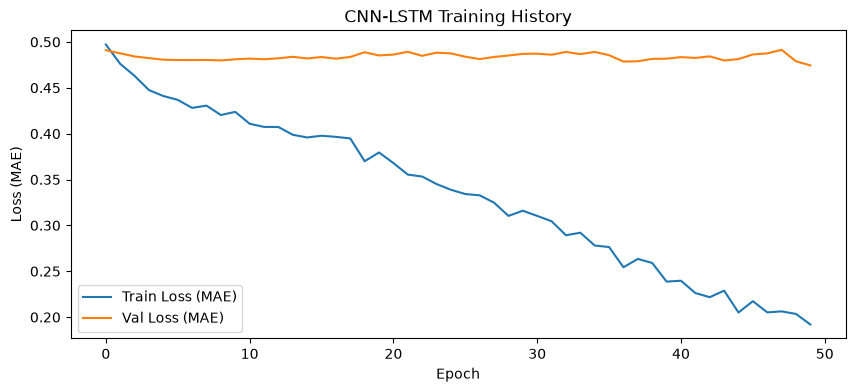

In [17]:
# 모델 생성, 학습 및 평가 수행
hybrid_model = build_and_train_hybrid_model(X_train, X_test, y_train, y_test)